Тема:
«Исследование и сравнение методов понижения размерности и кластеризации на реальном высокоразмерном датасете (из области по выбору: биоинформатика, тексты, изображения, графы) с анализом устойчивости и интерпретируемости полученных кластеров».

Основные требования к проекту:

Выбор и обоснование одного или двух реальных высокоразмерных датасетов (например, single‑cell RNA‑seq, embedding‑представления текстов, feature‑описания изображений).

Построение и сравнение нескольких пайплайнов «DR → кластеризация» (минимум 3 DR‑метода и 3 алгоритма кластеризации) с оценкой качества, устойчивости и практической интерпретации кластеров.

In [40]:
from sklearn.datasets import fetch_20newsgroups

cats = ['sci.crypt', 'rec.sport.baseball', 'misc.forsale']

newsgroups = fetch_20newsgroups(subset='all', categories=cats)
newsgroups.target.shape

(2960,)

In [41]:
newsgroups.data[0]

"From: pmetzger@snark.shearson.com (Perry E. Metzger)\nSubject: Re: Tempest\nOrganization: Partnership for an America Free Drug\nDistribution: na\nLines: 11\n\nwhughes@lonestar.utsa.edu (William W. Hughes) writes:\n>Hell, just set up a spark jammer, or some other _very_ electrically-noisy\n>device.\n\nAs I've noted, you can likely get around that with a directional\nsensor. Phased array systems could completely defeat this scheme.\n\n--\nPerry Metzger\t\tpmetzger@shearson.com\n--\nLaissez faire, laissez passer. Le monde va de lui meme.\n"

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
vectors = vectorizer.fit_transform(newsgroups.data)
vectors.shape

(2960, 35335)

In [43]:
vectors.data[0]

np.float64(0.02311055873268497)

In [44]:
X = vectors

In [45]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X)

In [46]:
from sklearn.metrics import accuracy_score
import itertools

iterator = itertools.permutations([0, 1, 2])
max_acc = 0
order = {}

for x, y, z in iterator:
    cond = {0: x, 1: y, 2: z}
    y_pred_cond = [cond[x] for x in y_pred]

    acc = accuracy_score(newsgroups.target, y_pred_cond)
    if acc > max_acc:
        max_acc = acc
        order = cond

print(f"Точность: {max_acc:.4f}, X= {order[0]} Y= {order[1]} Z= {order[2]}")

Точность: 0.7672, X= 0 Y= 2 Z= 1


In [47]:
y = newsgroups.target

In [10]:
from umap import UMAP


umap = UMAP(n_components=2, random_state=42)

X_umap = umap.fit_transform(vectors)

c:\Users\Damir\Documents\Мага\Кластеры\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: title={'center': 'Предсказанный'}>

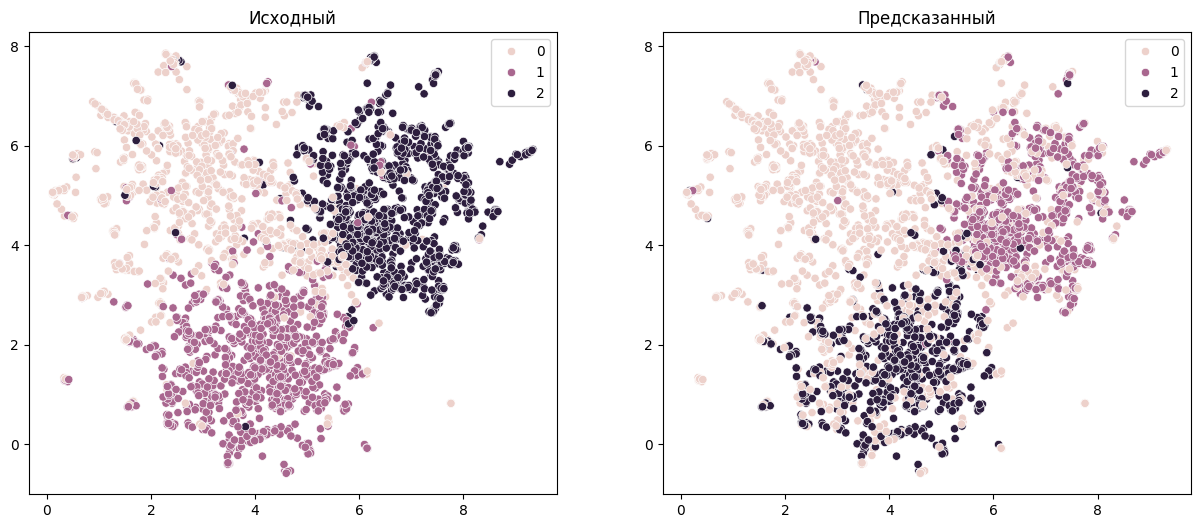

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
plt.title("Исходный")
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=newsgroups.target)
plt.subplot(1, 2, 2)
plt.title("Предсказанный")
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_pred)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
import umap.umap_ as umap
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, 
                             davies_bouldin_score, adjusted_rand_score,
                             adjusted_mutual_info_score, homogeneity_completeness_v_measure)
import warnings
warnings.filterwarnings('ignore')
import time

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class DRComparer:
    """Класс для сравнения различных методов уменьшения размерности"""
    
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.dr_methods = {}
        self.dr_results = {}
        
    def apply_pca(self, X, n_components=None, variance_threshold=0.95):
        """Применение PCA"""
        if n_components is None:
            pca = PCA(n_components=variance_threshold, random_state=self.random_state)
        else:
            pca = PCA(n_components=n_components, random_state=self.random_state)
        
        X_pca = pca.fit_transform(X)
        explained_variance = pca.explained_variance_ratio_
        
        self.dr_results['PCA'] = {
            'transformed': X_pca,
            'explained_variance': explained_variance,
            'n_components': X_pca.shape[1],
            'total_variance': explained_variance.sum()
        }
        
        return X_pca, pca
    
    def apply_isomap(self, X, n_components=2, n_neighbors=5):
        """Применение Isomap"""
        isomap = Isomap(n_components=n_components, n_neighbors=n_neighbors)
        X_isomap = isomap.fit_transform(X)
        
        self.dr_results['Isomap'] = {
            'transformed': X_isomap,
            'n_components': n_components,
            'n_neighbors': n_neighbors
        }
        
        return X_isomap, isomap
    
    def apply_tsne(self, X, n_components=2, perplexity=30, learning_rate=200):
        """Применение t-SNE"""
        tsne = TSNE(n_components=n_components, 
                   perplexity=perplexity,
                   learning_rate=learning_rate,
                   init="random",
                   n_jobs=-1)
        
        X_tsne = tsne.fit_transform(X)
        
        self.dr_results['t-SNE'] = {
            'transformed': X_tsne,
            'n_components': n_components,
            'perplexity': perplexity
        }
        
        return X_tsne, tsne
    
    def apply_umap(self, X, n_components=2, n_neighbors=15, min_dist=0.1):
        """Применение UMAP"""
        reducer = umap.UMAP(n_components=n_components,
                          n_neighbors=n_neighbors,
                          min_dist=min_dist,
                          random_state=self.random_state,
                          n_jobs=-1)
        
        X_umap = reducer.fit_transform(X)
        
        self.dr_results['UMAP'] = {
            'transformed': X_umap,
            'n_components': n_components,
            'n_neighbors': n_neighbors,
            'min_dist': min_dist
        }
        
        return X_umap, reducer
    
    def apply_all_methods(self, X, n_components_2d=2):
        """Применение всех методов DR"""
        print("Применение методов уменьшения размерности...")
        print("-" * 50)
        
        results = {}
        
        # PCA (сохраняем 95% дисперсии)
        start = time.time()
        X_pca, pca_model = self.apply_pca(X, n_components=n_components_2d, variance_threshold=0.95)
        pca_time = time.time() - start
        print(f"PCA выполнено за {pca_time:.2f} сек")
        print(f"  Компонент: {X_pca.shape[1]}, Объясненная дисперсия: {self.dr_results['PCA']['total_variance']:.3f}")
        
        # PCA для 2D визуализации
        pca_2d = PCA(n_components=n_components_2d, random_state=self.random_state)
        X_pca_2d = pca_2d.fit_transform(X)
        results['PCA_2D'] = X_pca_2d
        
        # Isomap
        start = time.time()
        X_isomap, isomap_model = self.apply_isomap(X, n_components=n_components_2d)
        isomap_time = time.time() - start
        print(f"Isomap выполнено за {isomap_time:.2f} сек")
        
        # t-SNE
        start = time.time()
        X_tsne, tsne_model = self.apply_tsne(X, n_components=n_components_2d)
        tsne_time = time.time() - start
        print(f"t-SNE выполнено за {tsne_time:.2f} сек")
        
        # UMAP
        start = time.time()
        X_umap, umap_model = self.apply_umap(X, n_components=n_components_2d)
        umap_time = time.time() - start
        print(f"UMAP выполнено за {umap_time:.2f} сек")
        
        # Сохраняем результаты
        results['PCA'] = X_pca
        results['PCA_2D'] = X_pca_2d
        results['Isomap'] = X_isomap
        results['t-SNE'] = X_tsne
        results['UMAP'] = X_umap
        
        # Информация о времени выполнения
        self.execution_times = {
            'PCA': pca_time,
            'Isomap': isomap_time,
            't-SNE': tsne_time,
            'UMAP': umap_time
        }
        
        return results

# Визуализация DR-результатов
def visualize_dr_results(dr_results, y_true):
    """Визуализация результатов различных методов DR"""
    
    methods = ['PCA_2D', 'Isomap', 't-SNE', 'UMAP']
    titles = ['PCA (2D)', 'Isomap', 't-SNE', 'UMAP']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx, (method, title) in enumerate(zip(methods, titles)):
        X_dr = dr_results[method]
        
        scatter = axes[idx].scatter(X_dr[:, 0], X_dr[:, 1], 
                                   c=y_true, cmap='tab10', 
                                   s=40, alpha=0.7, edgecolor='k', linewidth=0.5)
        
        axes[idx].set_title(f'{title}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Component 1')
        axes[idx].set_ylabel('Component 2')
        axes[idx].grid(True, alpha=0.3)
        
        # Добавляем цветовую шкалу для первого графика
        if idx == 0:
            plt.colorbar(scatter, ax=axes[idx], label='True Classes')
    
    plt.suptitle(f'DR Methods Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

Применение методов уменьшения размерности...
--------------------------------------------------
PCA выполнено за 0.15 сек
  Компонент: 2, Объясненная дисперсия: 0.030
Isomap выполнено за 2.02 сек
t-SNE выполнено за 21.34 сек
UMAP выполнено за 5.75 сек

Визуализация результатов DR-методов:


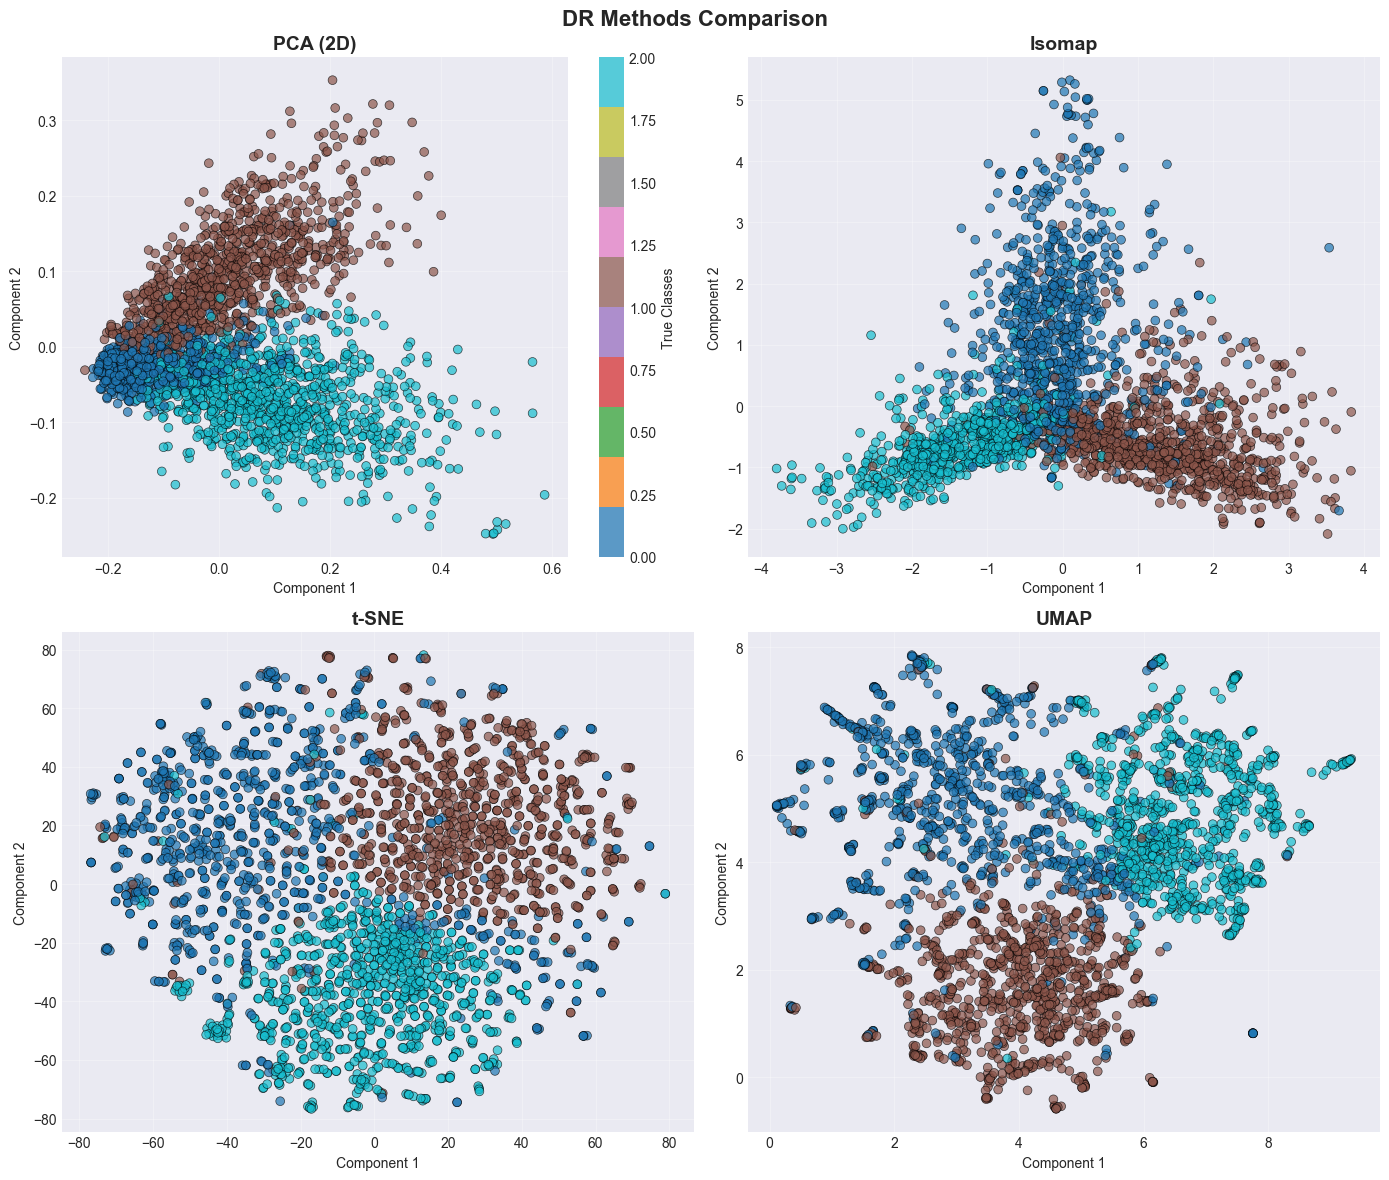

In [17]:
# Применение методов DR
dr_comparer = DRComparer(random_state=42)
dr_results = dr_comparer.apply_all_methods(X, n_components_2d=2)

# Визуализация
print("\nВизуализация результатов DR-методов:")
visualize_dr_results(dr_results, y)

In [21]:
class ClusteringEvaluator:
    """Комплексная система оценки качества кластеризации"""
    
    def __init__(self):
        self.results = {}
        
    def compute_all_metrics(self, X, labels, y_true=None, algorithm_name="", dr_method=""):
        """Вычисление всех метрик для кластеризации"""
        
        if len(np.unique(labels)) < 2:
            return {
                'n_clusters': len(np.unique(labels)),
                'internal_metrics': None,
                'external_metrics': None
            }
        
        # Внутренние метрики
        internal_metrics = {
            'silhouette': silhouette_score(X, labels),
            'calinski_harabasz': calinski_harabasz_score(X, labels),
            'davies_bouldin': davies_bouldin_score(X, labels)
        }
        
        # Внешние метрики (если есть истинные метки)
        external_metrics = None
        if y_true is not None:
            external_metrics = {
                'ari': adjusted_rand_score(y_true, labels),
                'ami': adjusted_mutual_info_score(y_true, labels),
                'homogeneity': homogeneity_completeness_v_measure(y_true, labels)[0],
                'completeness': homogeneity_completeness_v_measure(y_true, labels)[1],
                'v_measure': homogeneity_completeness_v_measure(y_true, labels)[2]
            }
        
        # Сохранение результатов
        key = f"{dr_method}_{algorithm_name}"
        self.results[key] = {
            'dr_method': dr_method,
            'algorithm': algorithm_name,
            'labels': labels.copy(),
            'n_clusters': len(np.unique(labels)),
            'internal_metrics': internal_metrics,
            'external_metrics': external_metrics
        }
        
        return {
            'n_clusters': len(np.unique(labels)),
            'internal_metrics': internal_metrics,
            'external_metrics': external_metrics
        }
    
    def print_metrics(self, metrics, algorithm_name, dr_method):
        """Печать метрик в читаемом формате"""
        print(f"\n{'='*70}")
        print(f"DR Метод: {dr_method} | Алгоритм: {algorithm_name}")
        print(f"{'='*70}")
        print(f"Количество кластеров: {metrics['n_clusters']}")
        
        if metrics['internal_metrics']:
            print("\nВНУТРЕННИЕ МЕТРИКИ:")
            print(f"  Silhouette Score:       {metrics['internal_metrics']['silhouette']:.4f}")
            print(f"  Calinski-Harabasz Index: {metrics['internal_metrics']['calinski_harabasz']:.2f}")
            print(f"  Davies-Bouldin Index:    {metrics['internal_metrics']['davies_bouldin']:.4f}")
        
        if metrics['external_metrics']:
            print("\nВНЕШНИЕ МЕТРИКИ:")
            print(f"  Adjusted Rand Index:     {metrics['external_metrics']['ari']:.4f}")
            print(f"  Adjusted MI:             {metrics['external_metrics']['ami']:.4f}")
            print(f"  V-measure:               {metrics['external_metrics']['v_measure']:.4f}")
            print(f"    Homogeneity:           {metrics['external_metrics']['homogeneity']:.4f}")
            print(f"    Completeness:          {metrics['external_metrics']['completeness']:.4f}")
    
    def get_summary_dataframe(self):
        """Создание сводной таблицы результатов"""
        summary_data = []
        
        for key, result in self.results.items():
            row = {
                'DR_Method': result['dr_method'],
                'Algorithm': result['algorithm'],
                'N_Clusters': result['n_clusters']
            }
            
            if result['internal_metrics']:
                row['Silhouette'] = result['internal_metrics']['silhouette']
                row['Calinski_Harabasz'] = result['internal_metrics']['calinski_harabasz']
                row['Davies_Bouldin'] = result['internal_metrics']['davies_bouldin']
            
            if result['external_metrics']:
                row['ARI'] = result['external_metrics']['ari']
                row['AMI'] = result['external_metrics']['ami']
                row['V_Measure'] = result['external_metrics']['v_measure']
            
            summary_data.append(row)
        
        return pd.DataFrame(summary_data)

# Алгоритмы кластеризации
class ClusteringAlgorithms:
    """Коллекция алгоритмов кластеризации"""
    
    def __init__(self, random_state=42):
        self.random_state = random_state
    
    def kmeans(self, X, n_clusters=10):
        """K-means кластеризация"""
        kmeans = KMeans(n_clusters=n_clusters, 
                       random_state=self.random_state,
                       n_init=10)
        return kmeans.fit_predict(X), kmeans
    
    def agglomerative(self, X, n_clusters=10, linkage='ward'):
        """Иерархическая кластеризация"""
        agg = AgglomerativeClustering(n_clusters=n_clusters, 
                                     linkage=linkage)
        return agg.fit_predict(X), agg
    
    def dbscan(self, X, eps=0.5, min_samples=5):
        """DBSCAN кластеризация"""
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        return dbscan.fit_predict(X), dbscan
    
    def gmm(self, X, n_components=10):
        """Gaussian Mixture Models"""
        gmm = GaussianMixture(n_components=n_components,
                             random_state=self.random_state)
        labels = gmm.fit_predict(X)
        return labels, gmm

In [33]:
def compare_clustering_on_dr(X_dict, y_true, n_clusters=3):
    """Сравнение алгоритмов кластеризации на разных DR-представлениях"""
    
    evaluator = ClusteringEvaluator()
    clustering = ClusteringAlgorithms(random_state=42)
    
    # Алгоритмы для тестирования
    algorithms = [
        ('KMeans', lambda X: clustering.kmeans(X, n_clusters=n_clusters)),
        ('Agglomerative', lambda X: clustering.agglomerative(X, n_clusters=n_clusters)),
        ('DBSCAN', lambda X: clustering.dbscan(X, eps=0.5, min_samples=5)),
        ('GMM', lambda X: clustering.gmm(X, n_components=n_clusters))
    ]
    
    results_comparison = {}
    
    for dr_name, X_dr in X_dict.items():
        if dr_name == 'PCA_2D':  # Пропускаем 2D представление для количественного анализа
            continue
        
        results_comparison[dr_name] = {}
        
        for algo_name, algo_func in algorithms:
            try:
                # Применение алгоритма кластеризации
                labels, model = algo_func(X_dr)
                
                # Вычисление метрик
                metrics = evaluator.compute_all_metrics(
                    X_dr, labels, y_true, algo_name, dr_name
                )
                
                # Сохранение для сравнения
                results_comparison[dr_name][algo_name] = {
                    'labels': labels,
                    'metrics': metrics
                }
                
            except Exception as e:
                print(f"Ошибка при выполнении {algo_name} на {dr_name}: {e}")
    
    return evaluator, results_comparison

# Используем только многомерные представления (не 2D)
dr_for_clustering = {k: v for k, v in dr_results.items() if k != 'PCA_2D'}
evaluator, comparison_results = compare_clustering_on_dr(dr_for_clustering, y, n_clusters=3)

# Получение сводной таблицы
summary_df = evaluator.get_summary_dataframe()
print("\nСВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print("="*80)
summary_df


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:


,DR_Method,Algorithm,N_Clusters,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI,AMI,V_Measure
0,PCA,KMeans,3,0.504768,3316.487995,0.798420,0.387305,0.455907,0.456256
1,PCA,Agglomerative,3,0.481738,2843.777564,0.734825,0.215348,0.366758,0.367189
2,PCA,GMM,3,0.375939,1981.680876,1.002668,0.683301,0.621757,0.621990
3,Isomap,KMeans,3,0.494949,3119.774265,0.689815,0.437270,0.469059,0.469399
4,Isomap,Agglomerative,3,0.467566,2806.432300,0.745944,0.447283,0.462537,0.462877
5,Isomap,DBSCAN,2,0.457752,7.011349,1.528991,0.000013,0.000071,0.000859
6,Isomap,GMM,3,0.417727,2154.983085,0.841248,0.438292,0.454416,0.454760
7,t-SNE,KMeans,3,0.424544,2710.029342,0.785913,0.673233,0.615898,0.616136
8,t-SNE,Agglomerative,3,0.359366,2097.086617,0.873932,0.405942,0.407366,0.407741
9,t-SNE,GMM,3,0.423664,2686.388601,0.789900,0.660509,0.609944,0.610185



ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МЕТРИК:


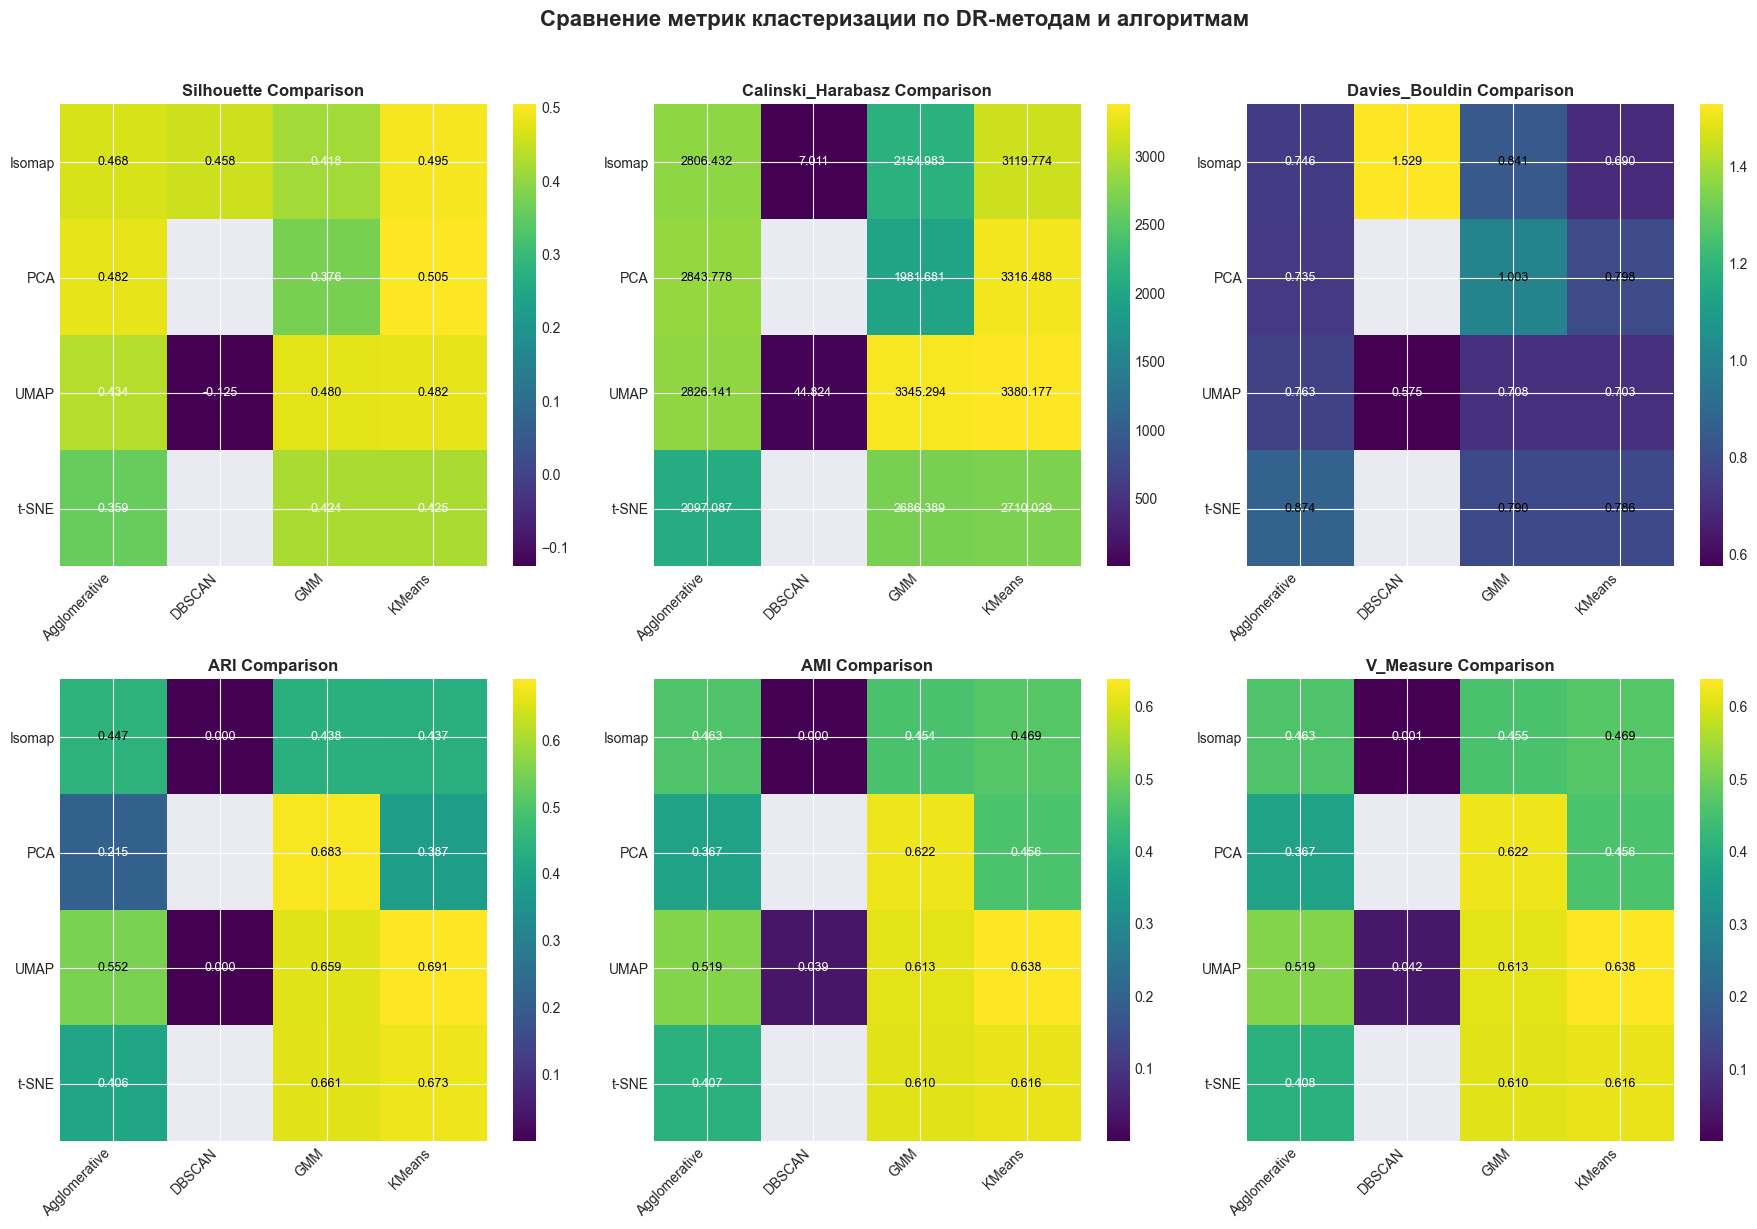


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ В 2D:


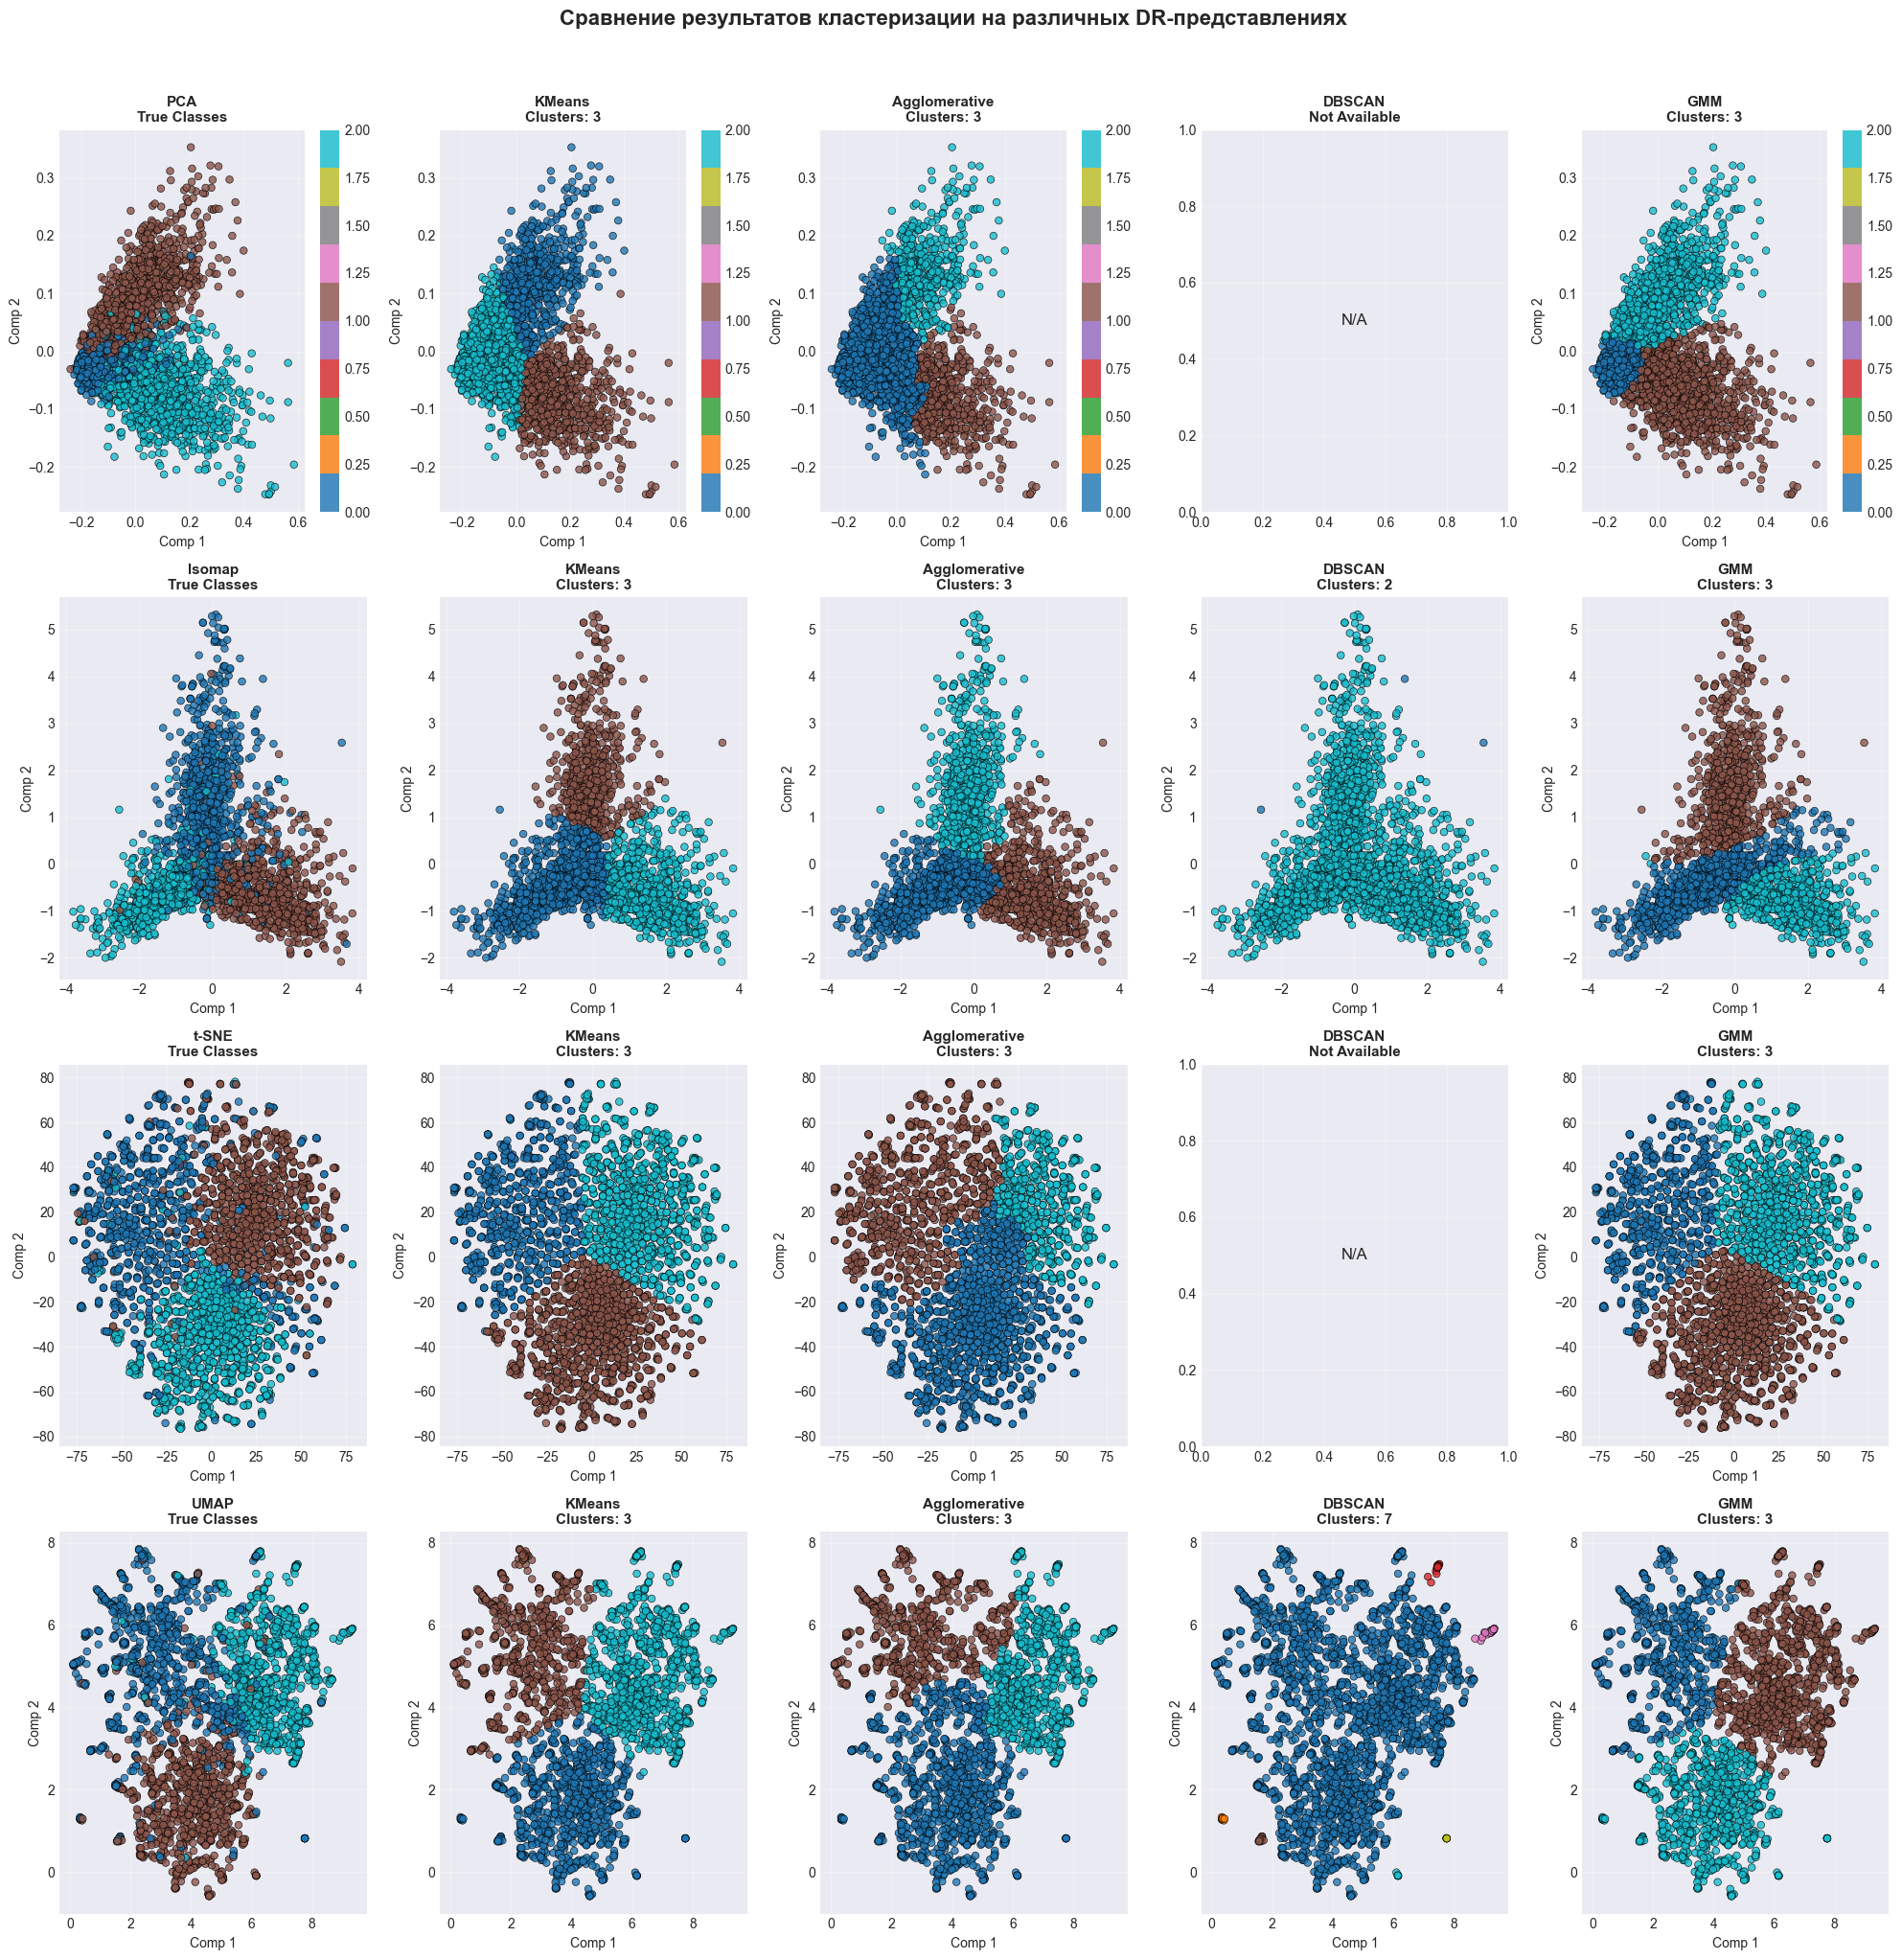

In [34]:
def visualize_metrics_comparison(summary_df):
    """Визуализация сравнения метрик по DR-методам и алгоритмам"""
    
    # Подготовка данных для визуализации
    metrics_to_plot = ['Silhouette', 'Calinski_Harabasz', 'Davies_Bouldin', 'ARI', 'AMI', 'V_Measure']
    
    # Создаем subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_to_plot):
        if metric in summary_df.columns:
            # Создаем pivot table для тепловой карты
            pivot_data = summary_df.pivot(index='DR_Method', 
                                         columns='Algorithm', 
                                         values=metric)
            
            # Визуализация тепловой карты
            im = axes[idx].imshow(pivot_data.values, cmap='viridis', aspect='auto')
            
            # Настройки осей
            axes[idx].set_xticks(np.arange(len(pivot_data.columns)))
            axes[idx].set_yticks(np.arange(len(pivot_data.index)))
            axes[idx].set_xticklabels(pivot_data.columns, rotation=45, ha='right')
            axes[idx].set_yticklabels(pivot_data.index)
            
            # Добавление значений в ячейки
            for i in range(len(pivot_data.index)):
                for j in range(len(pivot_data.columns)):
                    value = pivot_data.iloc[i, j]
                    if not pd.isna(value):
                        text = axes[idx].text(j, i, f'{value:.3f}',
                                             ha="center", va="center", 
                                             color="w" if value < np.nanmedian(pivot_data.values) else "k",
                                             fontsize=9)
            
            axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
            
            # Добавление colorbar
            plt.colorbar(im, ax=axes[idx])
    
    plt.suptitle('Сравнение метрик кластеризации по DR-методам и алгоритмам', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Визуализация сравнения метрик
print("\nВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МЕТРИК:")
visualize_metrics_comparison(summary_df)

def visualize_clustering_results_2d(dr_results_2d, y_true, evaluator, dr_methods):
    """Визуализация результатов кластеризации в 2D пространстве"""
    
    # Получаем все уникальные комбинации DR-методов и алгоритмов
    unique_dr_methods = dr_methods
    algorithms = ['KMeans', 'Agglomerative', 'DBSCAN', 'GMM']
    
    # Создаем grid для визуализации
    fig, axes = plt.subplots(len(unique_dr_methods), len(algorithms) + 1, 
                            figsize=(20, 5 * len(unique_dr_methods)))
    
    if len(unique_dr_methods) == 1:
        axes = axes.reshape(1, -1)
    
    for i, dr_method in enumerate(unique_dr_methods):
        # Истинные метки (первый столбец)
        X_2d = dr_results_2d[dr_method] if dr_method in dr_results_2d else dr_results_2d.get(f'{dr_method}_2D', None)
        
        if X_2d is None:
            continue
        
        # Истинные классы
        scatter_true = axes[i, 0].scatter(X_2d[:, 0], X_2d[:, 1], 
                                         c=y_true, cmap='tab10', 
                                         s=30, alpha=0.8, edgecolor='k', linewidth=0.5)
        axes[i, 0].set_title(f'{dr_method}\nTrue Classes', fontsize=11, fontweight='bold')
        axes[i, 0].set_xlabel('Comp 1')
        axes[i, 0].set_ylabel('Comp 2')
        axes[i, 0].grid(True, alpha=0.3)
        
        if i == 0:
            plt.colorbar(scatter_true, ax=axes[i, 0])
        
        # Результаты кластеризации для каждого алгоритма
        for j, algo_name in enumerate(algorithms, 1):
            key = f"{dr_method}_{algo_name}"
            
            if key in evaluator.results:
                labels = evaluator.results[key]['labels']
                n_clusters = evaluator.results[key]['n_clusters']
                
                # Определяем цветовую карту
                unique_labels = np.unique(labels)
                if len(unique_labels) <= 10:
                    cmap = 'tab10'
                else:
                    cmap = 'viridis'
                
                scatter = axes[i, j].scatter(X_2d[:, 0], X_2d[:, 1], 
                                            c=labels, cmap=cmap,
                                            s=30, alpha=0.8, edgecolor='k', linewidth=0.5)
                
                axes[i, j].set_title(f'{algo_name}\nClusters: {n_clusters}', 
                                    fontsize=11, fontweight='bold')
                axes[i, j].set_xlabel('Comp 1')
                axes[i, j].set_ylabel('Comp 2')
                axes[i, j].grid(True, alpha=0.3)
                
                # Добавляем colorbar для первого ряда
                if i == 0 and len(unique_labels) <= 15:
                    plt.colorbar(scatter, ax=axes[i, j])
            else:
                axes[i, j].text(0.5, 0.5, 'N/A', 
                               ha='center', va='center', 
                               transform=axes[i, j].transAxes,
                               fontsize=12)
                axes[i, j].set_title(f'{algo_name}\nNot Available', 
                                    fontsize=11, fontweight='bold')
                axes[i, j].grid(True, alpha=0.3)
    
    plt.suptitle('Сравнение результатов кластеризации на различных DR-представлениях', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Визуализация результатов кластеризации в 2D
print("\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ В 2D:")
dr_methods_for_viz = ['PCA', 'Isomap', 't-SNE', 'UMAP']
dr_results_2d = {
    'PCA': dr_results['PCA_2D'],
    'Isomap': dr_results['Isomap'],
    't-SNE': dr_results['t-SNE'],
    'UMAP': dr_results['UMAP']
}
visualize_clustering_results_2d(dr_results_2d, y, evaluator, dr_methods_for_viz)

In [35]:
from sklearn.cluster import OPTICS, Birch, SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import numpy as np
import pandas as pd

class AdvancedClustering:
    def __init__(self, random_state=42):
        self.random_state = random_state
    
    def optics(self, X, min_samples=4):
        model = OPTICS(min_samples=min_samples, xi=0.05, min_cluster_size=0.03)
        labels = model.fit_predict(X)
        return labels, model
    
    def spectral(self, X, n_clusters=10):
        model = SpectralClustering(n_clusters=n_clusters, 
                                   random_state=self.random_state,
                                   assign_labels='kmeans')
        labels = model.fit_predict(X)
        return labels, model
    
    def birch(self, X, n_clusters=10, threshold=0.05):
        model = Birch(n_clusters=n_clusters, threshold=threshold)
        labels = model.fit_predict(X)
        return labels, model

def compare_advanced_algorithms(X, y, dr_methods):
    results = []
    advanced = AdvancedClustering()

    n_true_clusters = len(np.unique(y))
    print(f"Истинное количество кластеров: {n_true_clusters}")
    
    algorithms = [
        ('OPTICS', lambda X: advanced.optics(X, min_samples=3)),
        ('Spectral', lambda X: advanced.spectral(X, n_clusters=n_true_clusters)),
        ('BIRCH', lambda X: advanced.birch(X, n_clusters=n_true_clusters))
    ]
    
    for dr_name, X_dr in dr_methods.items():
        print(f"\n{dr_name}:")
        for algo_name, algo_func in algorithms:
            labels, _ = algo_func(X_dr)
            
            if algo_name == 'OPTICS':
                mask = labels != -1
                n_clusters_found = len(np.unique(labels[mask]))
                n_non_noise = mask.sum()
                
                print(f"  {algo_name}: найдено {n_clusters_found} кластеров, "
                      f"{n_non_noise} точек не шум (всего точек: {len(labels)})")
                
                if n_clusters_found >= 2 and n_non_noise >= n_clusters_found * 2:
                    sil = silhouette_score(X_dr[mask], labels[mask])
                    ari = adjusted_rand_score(y[mask], labels[mask])
                    results.append({'DR_Method': dr_name, 'Algorithm': algo_name,
                                    'Silhouette': sil, 'ARI': ari,
                                    'n_clusters': n_clusters_found,
                                    'noise_ratio': 1 - n_non_noise/len(labels)})
                    print(f"Silhouette={sil:.4f}, ARI={ari:.4f}")
                else:
                    print(f"Недостаточно кластеров для оценки "
                          f"(нужно >=2 кластера, найдено {n_clusters_found})")
            
            else:
                n_clusters_found = len(np.unique(labels))
                
                print(f"  {algo_name}: найдено {n_clusters_found} кластеров")
                
                if n_clusters_found >= 2:
                    sil = silhouette_score(X_dr, labels)
                    ari = adjusted_rand_score(y, labels)
                    results.append({'DR_Method': dr_name, 'Algorithm': algo_name,
                                    'Silhouette': sil, 'ARI': ari,
                                    'n_clusters': n_clusters_found,
                                    'noise_ratio': 0})
                    print(f"Silhouette={sil:.4f}, ARI={ari:.4f}")
                else:
                    print(f"Недостаточно кластеров для оценки "
                          f"(нужно >=2, найдено {n_clusters_found})")
    
    return pd.DataFrame(results)

In [48]:
dr_methods = {'PCA': PCA(n_components=2).fit_transform(X),
              't-SNE': TSNE(n_components=2, init="random").fit_transform(X),
              'UMAP': umap.UMAP(n_components=2, random_state=42).fit_transform(X)}

In [37]:
advanced_results = compare_advanced_algorithms(X, y, dr_methods)

Истинное количество кластеров: 3

PCA:
  OPTICS: найдено 2 кластеров, 245 точек не шум (всего точек: 2960)
Silhouette=0.4365, ARI=0.0072
  Spectral: найдено 3 кластеров
Silhouette=0.4992, ARI=0.4074
  BIRCH: найдено 3 кластеров
Silhouette=0.3944, ARI=0.0560

t-SNE:
  OPTICS: найдено 1 кластеров, 2930 точек не шум (всего точек: 2960)
Недостаточно кластеров для оценки (нужно >=2 кластера, найдено 1)


KeyboardInterrupt: 

In [38]:
class ClusteringAlgorithms:

    def __init__(self, random_state=42):
        self.random_state = random_state
    
    def kmeans(self, X, n_clusters=10):
        kmeans = KMeans(n_clusters=n_clusters, 
                       random_state=self.random_state,
                       n_init=10)
        return kmeans.fit_predict(X), kmeans
    
    def agglomerative(self, X, n_clusters=10, linkage='ward'):
        agg = AgglomerativeClustering(n_clusters=n_clusters, 
                                     linkage=linkage)
        return agg.fit_predict(X), agg
    
    def dbscan(self, X, eps=0.5, min_samples=5):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        return dbscan.fit_predict(X), dbscan
    
    def gmm(self, X, n_components=10):
        gmm = GaussianMixture(n_components=n_components,
                             random_state=self.random_state)
        labels = gmm.fit_predict(X)
        return labels, gmm

def stability_analysis(X, y, dr_method, clustering_algo, n_iterations=10):
    sil_scores = []
    ari_scores = []
    
    n_samples = len(X.shape[0])
    for i in range(n_iterations):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        X_boot = X[indices]
        y_boot = y[indices]
        
        X_dr = dr_method.fit_transform(X_boot)
        
        labels, _ = clustering_algo(X_dr)
        
        if len(np.unique(labels)) > 1:
            sil = silhouette_score(X_dr, labels)
            ari = adjusted_rand_score(y, labels)
            sil_scores.append(sil)
            ari_scores.append(ari)
    
    return {
        'silhouette_mean': np.mean(sil_scores),
        'silhouette_std': np.std(sil_scores),
        'ari_mean': np.mean(ari_scores),
        'ari_std': np.std(ari_scores)
    }

def analyze_stability_all(X, y, dr_methods):
    results = []
    clustering = ClusteringAlgorithms()
    
    algorithms = [
        ('KMeans', lambda X: clustering.kmeans(X, n_clusters=len(np.unique(y)))),
        ('Agglomerative', lambda X: clustering.agglomerative(X, n_clusters=len(np.unique(y))))
    ]
    
    print("Анализ устойчивости:")
    for dr_name, dr_method in dr_methods.items():
        for algo_name, algo_func in algorithms:
            X_dr = dr_method.fit_transform(X)
            stability = stability_analysis(X, y, dr_method, algo_func, n_iterations=10)
            results.append({'DR_Method': dr_name, 'Algorithm': algo_name,
                            'Silhouette_Mean': stability['silhouette_mean'],
                            'Silhouette_Std': stability['silhouette_std'],
                            'ARI_Mean': stability['ari_mean'],
                            'ARI_Std': stability['ari_std']})
    
    return pd.DataFrame(results)

In [49]:
stability_results = analyze_stability_all(X, y, dr_methods)

Анализ устойчивости:


AttributeError: 'numpy.ndarray' object has no attribute 'fit_transform'